In [1]:
from typing import Literal, Dict, List, TypedDict

import shared_libraries.simulation as sim
import shared_libraries._simulation_utils as _simutils

import pandas as pd
import pickle

import statistics
import random

import matplotlib.pyplot as plt

In [2]:
with open("ig_models/models.pickle", "rb") as file:
    models = pickle.load(file)

In [3]:
circuit_lap_counts = pd.read_csv("./ig_data/circuit_lap_counts.csv", index_col=0)
circuit_lap_counts

,LapCount
Sakhir,57
Jeddah,50
Melbourne,58
Miami,57
Catalunya,66
Monte Carlo,78
Baku,51
Montreal,70
Silverstone,52
Paul Ricard,53


In [4]:
compound_mappings = sim.prepare_example_compound_mappings()
weathers = sim.prepare_example_weather_data()
simulation_results = sim.prepare_simulation(
    ["Austin", "Spielberg"],
    compound_mappings,
    weathers,
    circuit_lap_counts
)

In [5]:
simulation_results["WeatherAndMappingCombinations"]

,Id,WeatherName,CompoundMappingName
0,0,Desert,Fast
1,1,Desert,Medium
2,2,Desert,Durable
3,3,Tropical,Fast
4,4,Tropical,Medium
5,5,Tropical,Durable
6,6,Temperate,Fast
7,7,Temperate,Medium
8,8,Temperate,Durable
9,9,Desert,Fast


In [6]:
simulation_results["FullStrategyData"]["Austin"][0]["Laps"]

,StrategyId,LapNumber,TyreLife,IsPitLap,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindSpeed,...,RealCompound_C3,RealCompound_C4,RealCompound_C5,WindDirection_N,WindDirection_NE,WindDirection_E,WindDirection_SE,WindDirection_S,WindDirection_SW,WindDirection_W
0,0,1,1,False,33,28,1009,False,42,8,...,False,False,False,False,False,False,False,False,False,False
1,0,2,2,False,33,28,1009,False,42,8,...,False,False,False,False,False,False,False,False,False,False
2,0,3,3,False,33,28,1009,False,42,8,...,False,False,False,False,False,False,False,False,False,False
3,0,4,4,False,33,28,1009,False,42,8,...,False,False,False,False,False,False,False,False,False,False
4,0,5,5,False,33,28,1009,False,42,8,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40035,714,52,23,False,33,28,1009,False,42,8,...,True,False,False,False,False,False,False,False,False,False
40036,714,53,24,False,33,28,1009,False,42,8,...,True,False,False,False,False,False,False,False,False,False
40037,714,54,25,False,33,28,1009,False,42,8,...,True,False,False,False,False,False,False,False,False,False
40038,714,55,26,False,33,28,1009,False,42,8,...,True,False,False,False,False,False,False,False,False,False


Evaluating strategy with ID of 0...
Evaluating strategy with ID of 1...
Evaluating strategy with ID of 2...
Evaluating strategy with ID of 3...
Evaluating strategy with ID of 4...
Evaluating strategy with ID of 5...
Evaluating strategy with ID of 6...
Evaluating strategy with ID of 7...
Evaluating strategy with ID of 8...
Evaluating strategy with ID of 9...
Evaluating strategy with ID of 10...
Evaluating strategy with ID of 11...
Evaluating strategy with ID of 12...
Evaluating strategy with ID of 13...
Evaluating strategy with ID of 14...
Evaluating strategy with ID of 15...
Evaluating strategy with ID of 16...
Evaluating strategy with ID of 17...
Evaluating strategy with ID of 18...
Evaluating strategy with ID of 19...
Evaluating strategy with ID of 20...
Evaluating strategy with ID of 21...
Evaluating strategy with ID of 22...
Evaluating strategy with ID of 23...
Evaluating strategy with ID of 24...
Evaluating strategy with ID of 25...
Evaluating strategy with ID of 26...
Evaluating 

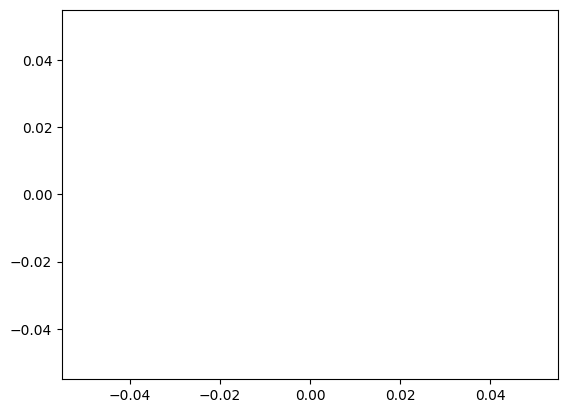

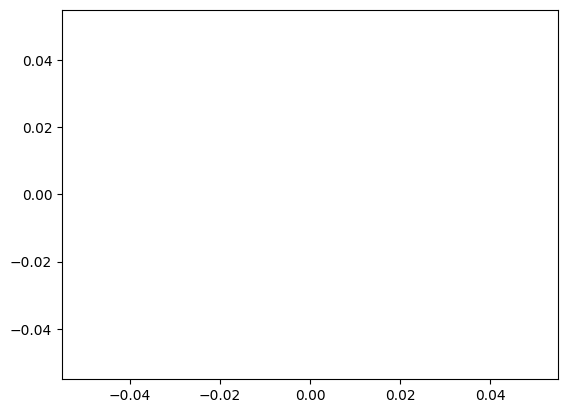

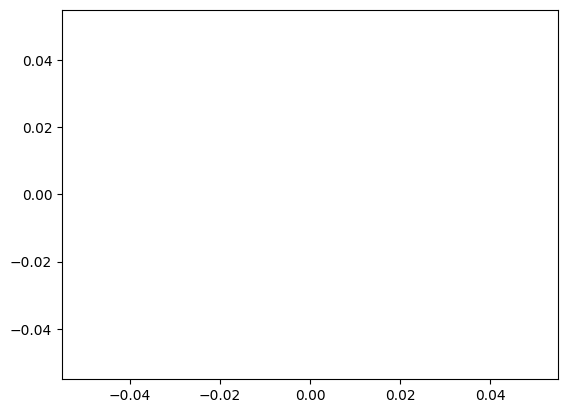

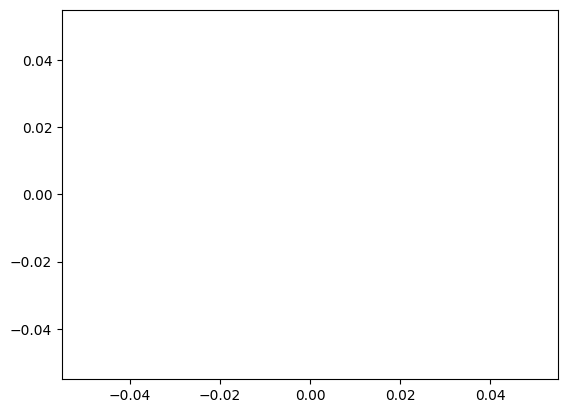

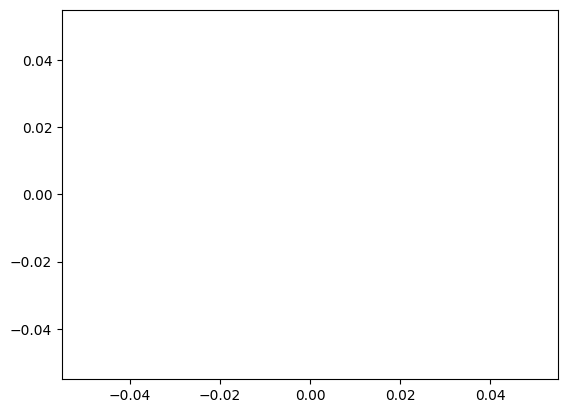

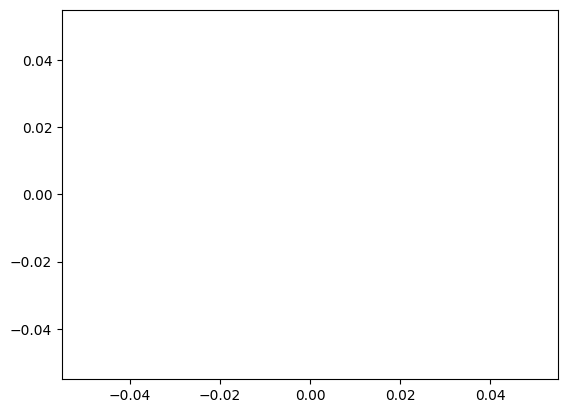

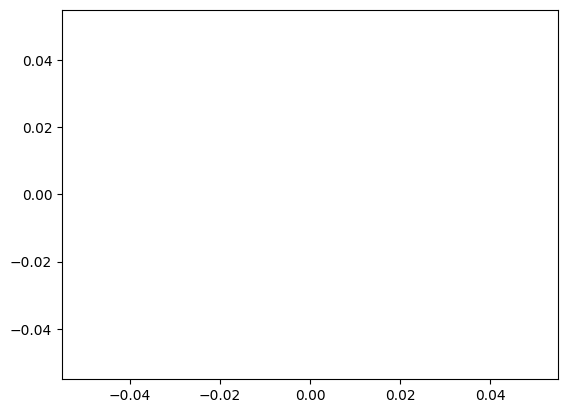

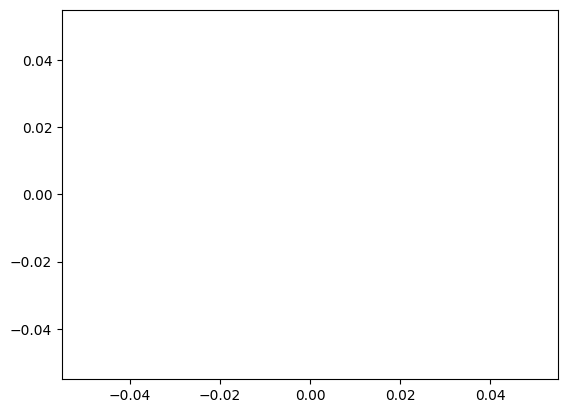

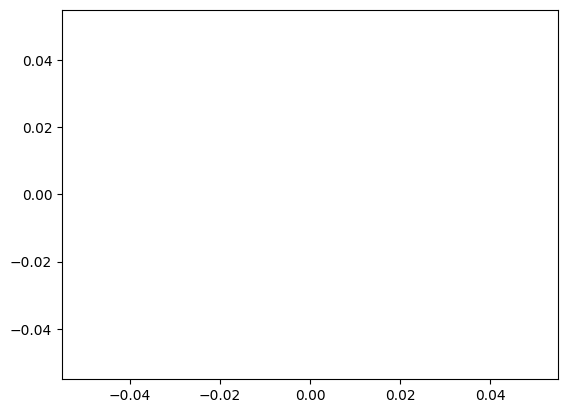

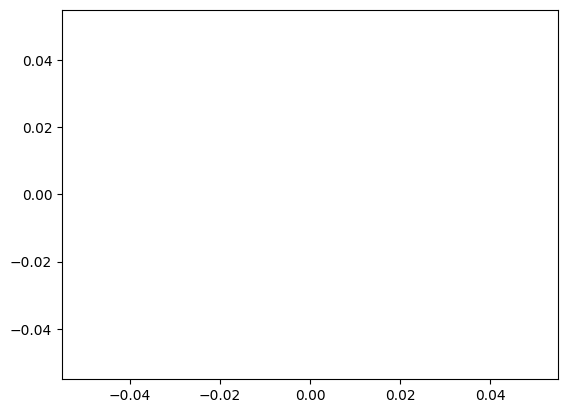

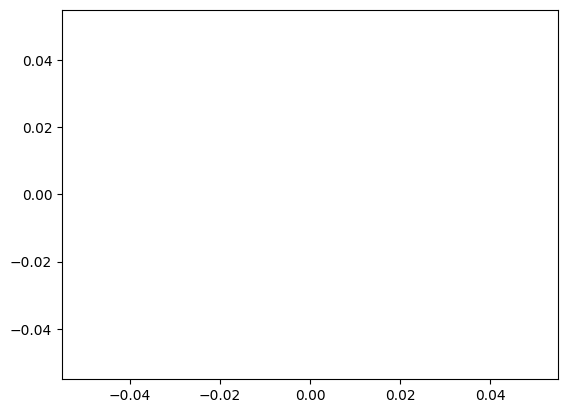

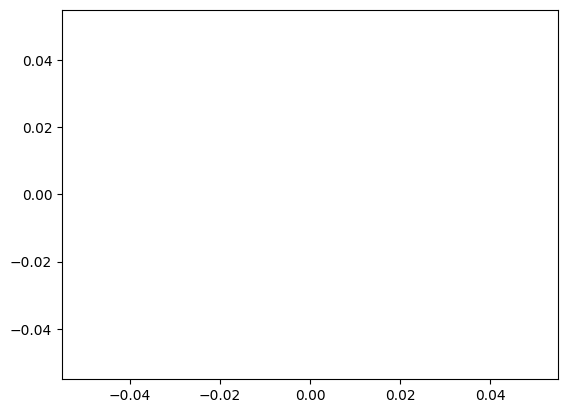

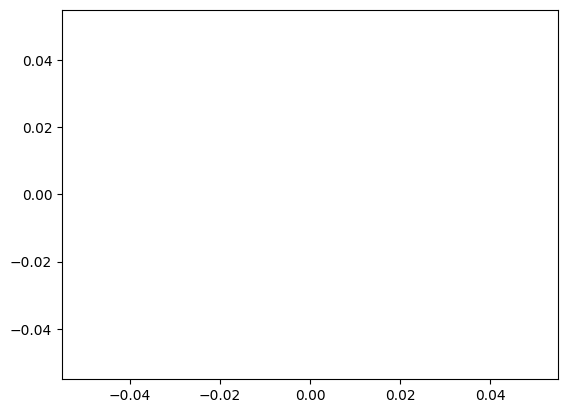

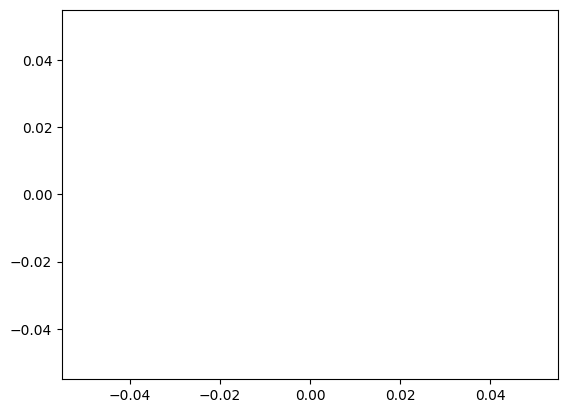

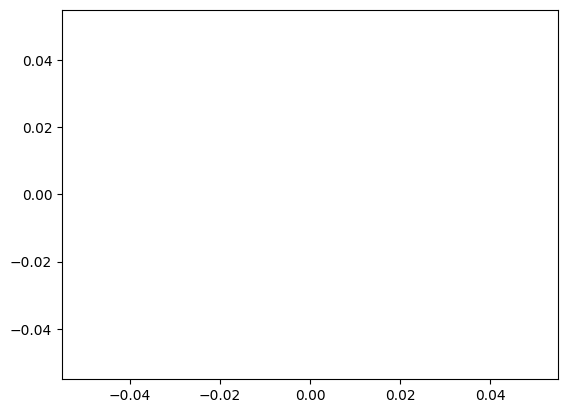

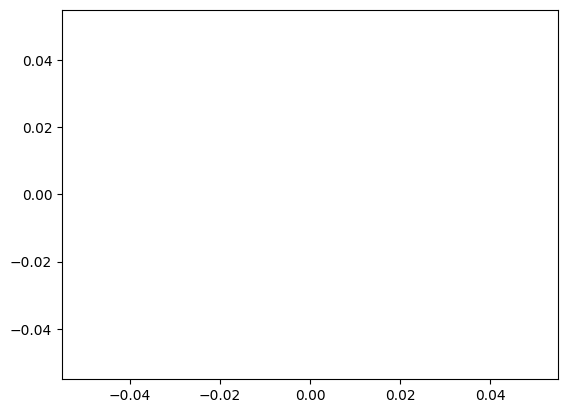

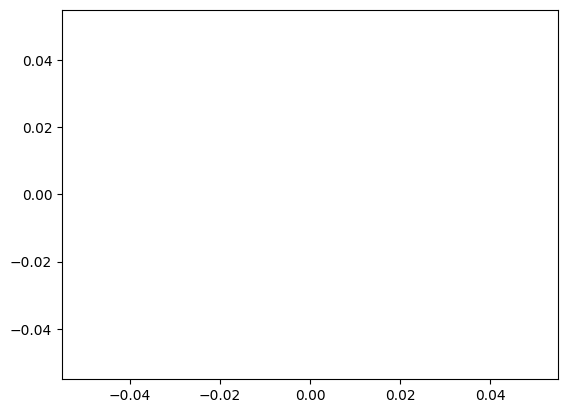

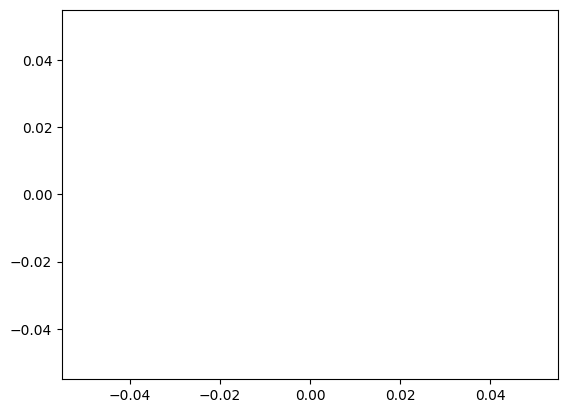

In [7]:


for circuit, strategy_data_by_conditions in simulation_results["FullStrategyData"].items():
    model = models[circuit]["XGBRegressor"].best_estimator_
    for conditions_id, strategy_data in strategy_data_by_conditions.items():
        laps = strategy_data["Laps"]
        strategies = strategy_data["Strategies"]
        strategies = _simutils.evaluate_strategies(strategy_data, model)
        conditions = simulation_results["WeatherAndMappingCombinations"].loc[conditions_id]
        mapping_name: str = conditions["WeatherName"] # type: ignore
        weather_name: str = conditions["CompoundMappingName"] # type: ignore

        path = f"./figures/simulation_results/{circuit}/{weather_name.replace(' ', '_')}__{mapping_name.replace(' ', '_')}"
        fig, ax = plt.subplots()
        ax.plot()
        


In [9]:
strategies

,Id,Strategy
0,0,"Strategy[['SOFT', 'MEDIUM'], [39]]"
1,1,"Strategy[['SOFT', 'HARD'], [39]]"
2,2,"Strategy[['MEDIUM', 'HARD'], [39]]"
3,3,"Strategy[['SOFT', 'MEDIUM'], [38]]"
4,4,"Strategy[['SOFT', 'HARD'], [38]]"
...,...,...
710,710,"Strategy[['SOFT', 'MEDIUM', 'MEDIUM'], [14, 29]]"
711,711,"Strategy[['SOFT', 'MEDIUM', 'HARD'], [14, 29]]"
712,712,"Strategy[['SOFT', 'HARD', 'HARD'], [14, 29]]"
713,713,"Strategy[['MEDIUM', 'MEDIUM', 'HARD'], [14, 29]]"
